# Paper depth analyses — repeated splits, baselines, transfer breakdown, timing, interpretation, EDA, workflow schematic
Everything feeds `Model/paper_figures/`; hyperparameters are reused from `interp_row_42` (no re-tuning).

In [1]:
import sys, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import ldh_pipeline as lp

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 12, 'savefig.dpi': 300,
})
SEED = lp.SEED
FIG_DIR = lp.MODEL_DIR / 'paper_figures'
FIG_DIR.mkdir(exist_ok=True)
print('Figures ->', FIG_DIR)

Figures -> /home/trunght/workspace/researches/Green-X Project-BaoTien/Model/paper_figures


In [2]:
df = lp.load_data(lp.DATA_DIR / '20260804_Data_Adsorption.xlsx')
y_full = df['RR %']
groups_full = df['Id'].values
X_full = df.drop(columns=['Id', 'RR %'])
saved = joblib.load(lp.MODEL_DIR / 'interp_row_42' / 'saved_models.joblib')
MODELS = {k: saved[k] for k in ('LR', 'KNN', 'ANN', 'Cubist', 'RF', 'XGB', 'HistGB')}

# duplicate-free view for the interpolation task (matches interp_row_42)
keep = ~X_full.duplicated(keep='first')
Xd = X_full[keep].reset_index(drop=True)
yd = y_full[keep].reset_index(drop=True)
ids_d = df['Id'][keep].reset_index(drop=True)
tp_d = df['TP'][keep].reset_index(drop=True)
print(f"full: {len(df)} rows | dedup: {len(Xd)} rows | studies: {ids_d.nunique()}")

full: 1342 rows | dedup: 1259 rows | studies: 57


## A1. Repeated-split interpolation (20 seeded 80/20 splits) + naive baselines

In [3]:
rep = lp.repeated_interpolation(MODELS, Xd, yd, n_repeats=20)
rep.to_csv(FIG_DIR / 'repeated_interp_models.csv', index=False)
base = lp.baseline_repeated_interpolation(
    yd, keys={'per-pollutant mean': tp_d, 'per-study mean': ids_d}, n_repeats=20)
base.to_csv(FIG_DIR / 'repeated_interp_baselines.csv', index=False)

both = pd.concat([rep, base])
summ = both.groupby('model')[['r2', 'mae', 'rmse']].agg(['mean', 'std']).round(3)
summ.columns = ['_'.join(c) for c in summ.columns]
summ = summ.sort_values('mae_mean')
summ.to_csv(FIG_DIR / 'repeated_interp_summary.csv')
summ

,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
model,,,,,,
XGB,0.842,0.029,6.277,0.558,11.092,0.952
HistGB,0.850,0.028,6.344,0.530,10.785,0.957
KNN,0.733,0.061,7.821,0.805,14.372,1.467
Cubist,0.793,0.032,8.041,0.566,12.723,0.967
RF,0.784,0.033,8.608,0.480,12.974,0.921
ANN,0.536,0.045,14.411,0.699,19.062,0.904
per-study mean,0.427,0.053,16.665,0.801,21.178,0.947
LR,0.400,0.040,17.391,0.544,21.702,0.731
per-pollutant mean,0.179,0.030,21.422,0.606,25.388,0.640


## A2. LOSO baselines — do the models beat a per-pollutant average for a new study?

In [4]:
loso = pd.read_csv(FIG_DIR / 'loso_per_study.csv')
bl = lp.baseline_loso(y_full, groups_full, keys={'per-pollutant mean': df['TP']})
bl.to_csv(FIG_DIR / 'loso_baselines.csv', index=False)

print('LOSO median MAE:')
print(pd.concat([loso.groupby('model')['mae'].median(),
                 bl.groupby('model')['mae'].median()]).sort_values().round(2))

best = loso[loso.model == 'Cubist'][['study', 'mae']].rename(columns={'mae': 'model_mae'})
tp_bl = bl[bl.model == 'per-pollutant mean'][['study', 'mae']].rename(columns={'mae': 'baseline_mae'})
head2head = best.merge(tp_bl, on='study')
wins = (head2head.model_mae < head2head.baseline_mae).sum()
print(f"Cubist beats the per-pollutant-mean baseline in {wins} of {len(head2head)} studies")
pd.DataFrame([{'model': 'Cubist', 'wins': wins, 'n': len(head2head)}]).to_csv(
    FIG_DIR / 'loso_head2head.csv', index=False)

LOSO median MAE:
model
Cubist                14.11
KNN                   16.00
HistGB                16.40
RF                    16.81
ANN                   18.13
XGB                   18.33
global mean           24.23
per-pollutant mean    25.13
LR                    28.40
Name: mae, dtype: float64
Cubist beats the per-pollutant-mean baseline in 41 of 59 studies


## A3. Transfer breakdown — which chemistries transfer?

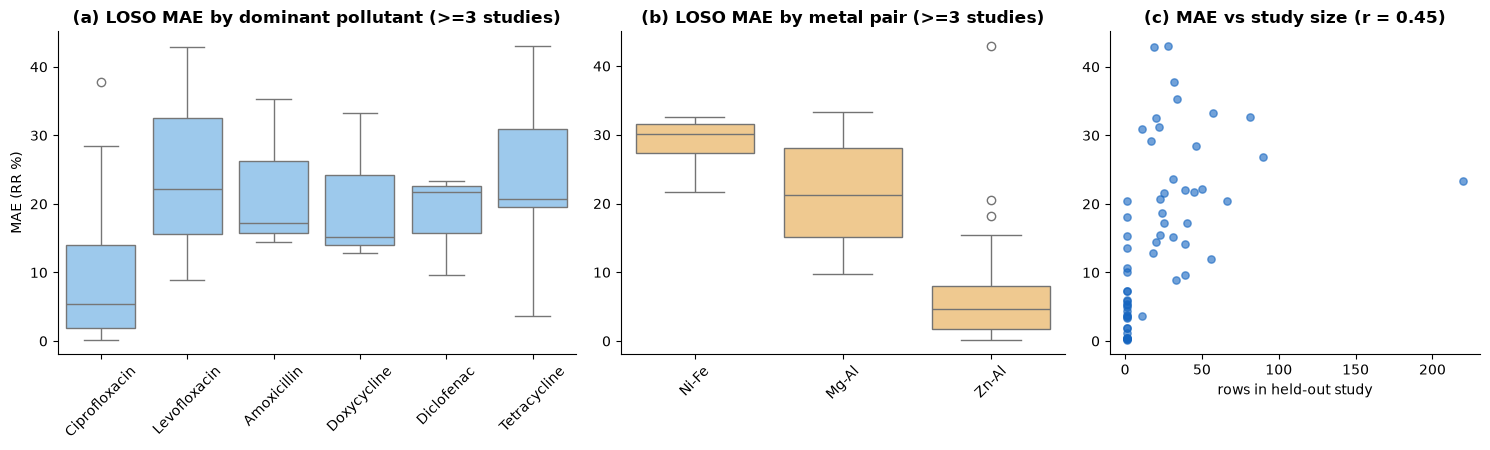

spread corr r(rr_spread, mae) = 0.45


In [5]:
attrs = (df.groupby('Id').agg(
    tp=('TP', lambda s: s.mode().iat[0]),
    metal2=('Metal(II)', lambda s: s.mode().iat[0]),
    metal3=('Metal(III)', lambda s: s.mode().iat[0]),
    n_rows=('TP', 'size'),
    rr_spread=('RR %', 'std'))
    .reset_index().rename(columns={'Id': 'study'}))
attrs['metal_pair'] = attrs['metal2'] + '-' + attrs['metal3']
tb = loso[loso.model == 'Cubist'].drop(columns=['n_rows']).merge(attrs, on='study')
tb.to_csv(FIG_DIR / 'transfer_breakdown.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), gridspec_kw={'width_ratios': [1.4, 1.2, 1]})
tp_counts = tb['tp'].value_counts()
tp_keep = tp_counts[tp_counts >= 3].index
sns.boxplot(data=tb[tb.tp.isin(tp_keep)], x='tp', y='mae', ax=axes[0], color='#90CAF9')
axes[0].set_title('(a) LOSO MAE by dominant pollutant (>=3 studies)')
axes[0].set_xlabel(''); axes[0].set_ylabel('MAE (RR %)')
axes[0].tick_params(axis='x', rotation=45)

mp_counts = tb['metal_pair'].value_counts()
mp_keep = mp_counts[mp_counts >= 3].index
sns.boxplot(data=tb[tb.metal_pair.isin(mp_keep)], x='metal_pair', y='mae', ax=axes[1],
            color='#FFCC80')
axes[1].set_title('(b) LOSO MAE by metal pair (>=3 studies)')
axes[1].set_xlabel(''); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

axes[2].scatter(tb['n_rows'], tb['mae'], alpha=0.6, s=28, color='#1565C0')
r_n = np.corrcoef(tb['n_rows'], tb['mae'])[0, 1]
axes[2].set_title(f'(c) MAE vs study size (r = {r_n:.2f})')
axes[2].set_xlabel('rows in held-out study'); axes[2].set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_transfer_breakdown.png', bbox_inches='tight')
plt.show()
print('spread corr r(rr_spread, mae) =', round(np.corrcoef(tb.dropna(subset=['rr_spread'])['rr_spread'], tb.dropna(subset=['rr_spread'])['mae'])[0,1], 2))

## A4. Computation time

In [6]:
Xtr, Xte, ytr, yte, _ = lp.make_split(Xd, yd, groups=None, test_size=0.2, seed=SEED)
rows = []
for name, model in MODELS.items():
    from sklearn.base import clone
    m = clone(model)
    t0 = time.perf_counter(); m.fit(Xtr, ytr); t_fit = time.perf_counter() - t0
    t0 = time.perf_counter(); m.predict(Xte); t_pred = time.perf_counter() - t0
    rows.append({'model': name, 'fit_s': round(t_fit, 2), 'predict_s': round(t_pred, 3)})
timing = pd.DataFrame(rows).sort_values('fit_s')
timing.to_csv(FIG_DIR / 'computation_time.csv', index=False)
timing

,model,fit_s,predict_s
0,LR,0.03,0.012
1,KNN,0.03,0.046
3,Cubist,0.17,0.030
4,RF,0.33,0.077
2,ANN,0.64,0.010
6,HistGB,0.73,0.083
5,XGB,7.37,0.021


## A5. Interpretation depth — multi-model permutation ranks, SHAP interaction, PDP

In [7]:
fitted = {}
for name, model in MODELS.items():
    from sklearn.base import clone
    m = clone(model); m.fit(Xtr, ytr); fitted[name] = {'model': m}
ranks = lp.permutation_ranks(fitted, Xte, yte)
ranks.to_csv(FIG_DIR / 'perm_ranks_all_models.csv')
ranks['median_rank'] = ranks.median(axis=1)
ranks.sort_values('median_rank').head(12)

,LR,KNN,ANN,Cubist,RF,XGB,HistGB,median_rank
AD g/L,27,1,29,1,1,1,1,1.0
Time h,19,3,1,2,2,2,2,2.0
Ci mg/L,22,4,14,3,3,4,3,4.0
pH,25,2,4,5,7,5,4,5.0
BET m2/g,24,5,2,7,6,6,6,6.0
pHpzc,26,7,19,9,4,7,5,7.0
d(003) nm,8,6,8,8,12,8,10,8.0
average Pauling electronegativity,15,13,7,15,9,9,8,9.0
Log Kow,11,9,16,18,5,3,7,9.0
PV cm3/g,10,16,12,4,8,10,9,10.0


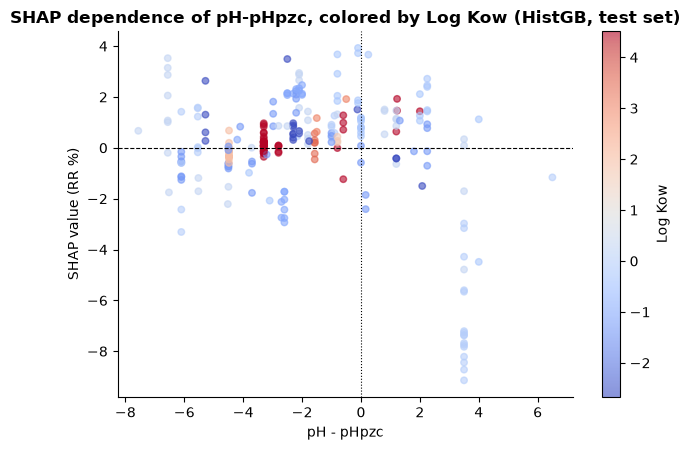

In [8]:
import shap
eng_models = joblib.load(lp.MODEL_DIR / 'interp_row_eng_42' / 'saved_models.joblib')
X_eng_full = lp.add_engineered_features(X_full)
keep_e = ~X_eng_full.duplicated(keep='first')
Xe = X_eng_full[keep_e].reset_index(drop=True)
ye = y_full[keep_e].reset_index(drop=True)
Xtr_e, Xte_e, ytr_e, yte_e, _ = lp.make_split(Xe, ye, groups=None, test_size=0.2, seed=SEED)
res_eng = {'model': eng_models['HistGB'], 'label': 'HistGB'}
sv, names = lp.shap_summary(res_eng, Xte_e)

j = names.index('pH-pHpzc'); k = names.index('Log Kow')
fig, ax = plt.subplots(figsize=(6.5, 4.6))
sc = ax.scatter(sv.data[:, j], sv.values[:, j], c=sv.data[:, k], cmap='coolwarm',
                alpha=0.6, s=22)
plt.colorbar(sc, label='Log Kow')
ax.axhline(0, color='k', lw=0.8, ls='--'); ax.axvline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel('pH - pHpzc'); ax.set_ylabel('SHAP value (RR %)')
ax.set_title('SHAP dependence of pH-pHpzc, colored by Log Kow (HistGB, test set)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_shap_interaction.png', bbox_inches='tight')
plt.show()

PDP features: ['AD g/L', 'Time h', 'Ci mg/L']


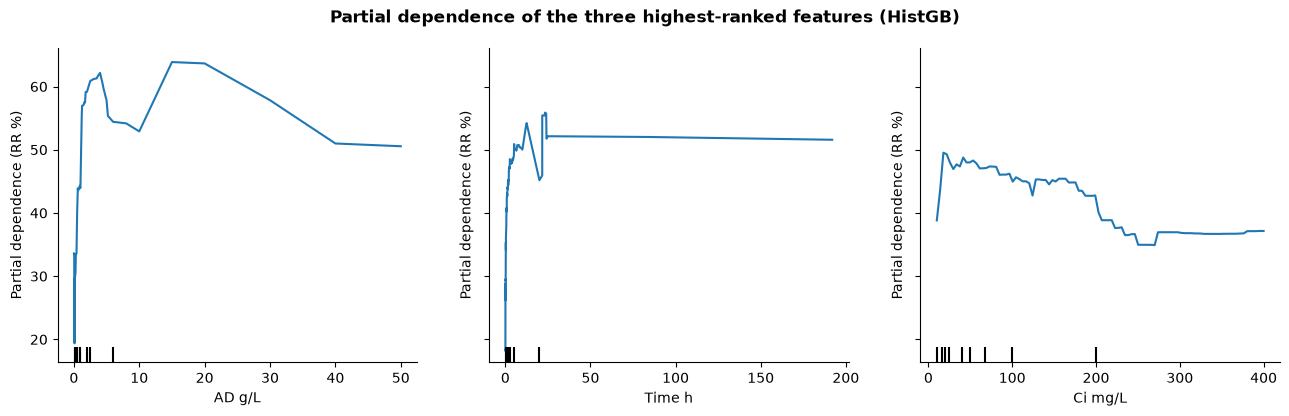

In [9]:
from sklearn.inspection import PartialDependenceDisplay
top3 = [f for f in ranks.sort_values('median_rank').index if f in Xd.columns][:3]
print('PDP features:', top3)
fig, ax = plt.subplots(figsize=(13, 4.2))
disp = PartialDependenceDisplay.from_estimator(
    fitted['HistGB']['model'], Xtr, top3, kind='average', ax=ax)
for a in disp.axes_.ravel():
    if a is not None:
        a.set_ylabel('Partial dependence (RR %)')
plt.suptitle('Partial dependence of the three highest-ranked features (HistGB)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_pdp.png', bbox_inches='tight')
plt.show()

## A6. EDA package — summary statistics, correlations, target distributions

                                   median     min      max  missing_%
Log Kow                             -0.02   -2.67     4.51        0.0
MW g/mol                           331.34  152.15   733.93        0.0
E                                    1.81    0.70     3.60        0.0
S                                    2.10    0.70     3.60        0.0
A                                    0.70    0.31     1.65        0.0
B                                    1.70    0.45     3.50        0.0
V                                    2.30    1.13     6.35        0.0
TSPA                                76.20   37.30   194.00        0.0
M(II)/(III)                          3.00    0.50     8.00        0.0
average atomic weight (g/mol)       48.06   24.84    73.68        0.0
average d-electron                   4.25    0.00     8.89        0.0
average Pauling electronegativity    1.59    1.30     1.89        0.0
TemH oC                             70.00   25.00   160.00       13.3
HT hour             

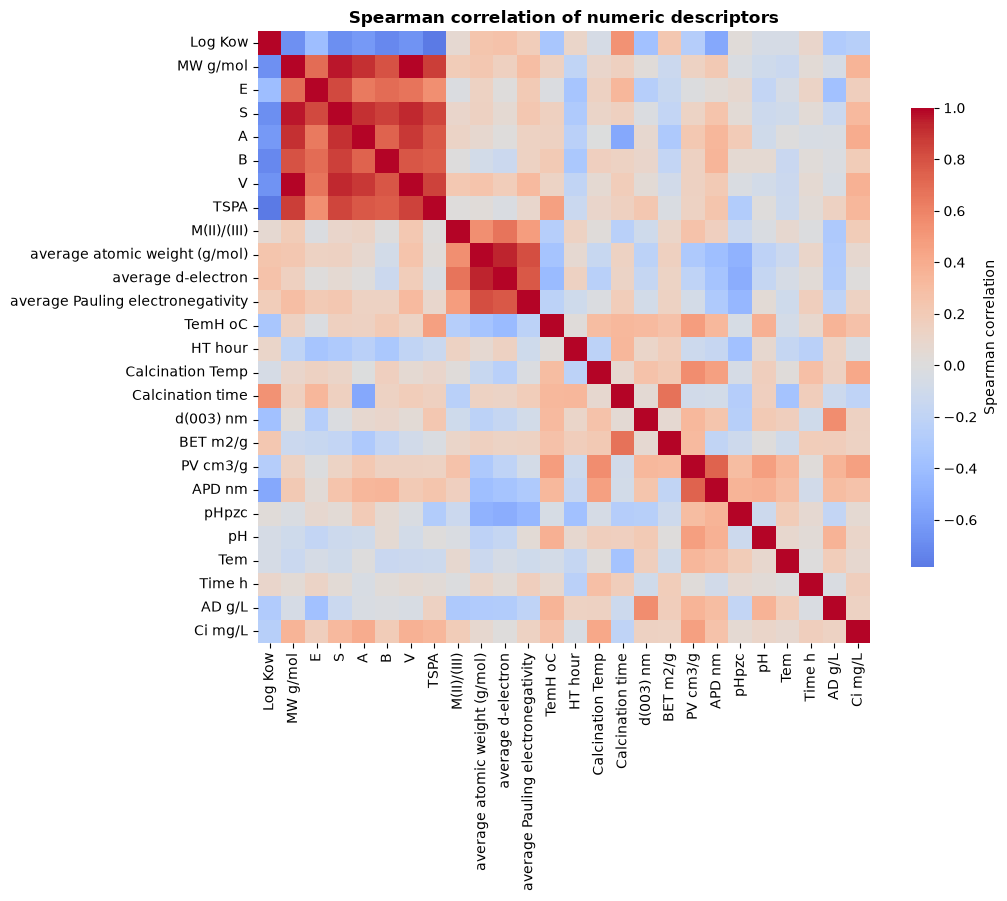

In [10]:
num = X_full.select_dtypes(include=[np.number])
stats = pd.DataFrame({
    'median': num.median(), 'min': num.min(), 'max': num.max(),
    'missing_%': (num.isna().mean() * 100).round(1)}).round(2)
stats.to_csv(FIG_DIR / 'descriptor_stats.csv')
print(stats)

fig, ax = plt.subplots(figsize=(11, 9))
corr = num.corr(method='spearman')
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, square=True,
            cbar_kws={'shrink': 0.75, 'label': "Spearman correlation"})
ax.set_title('Spearman correlation of numeric descriptors')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_corr_heatmap.png', bbox_inches='tight')
plt.show()

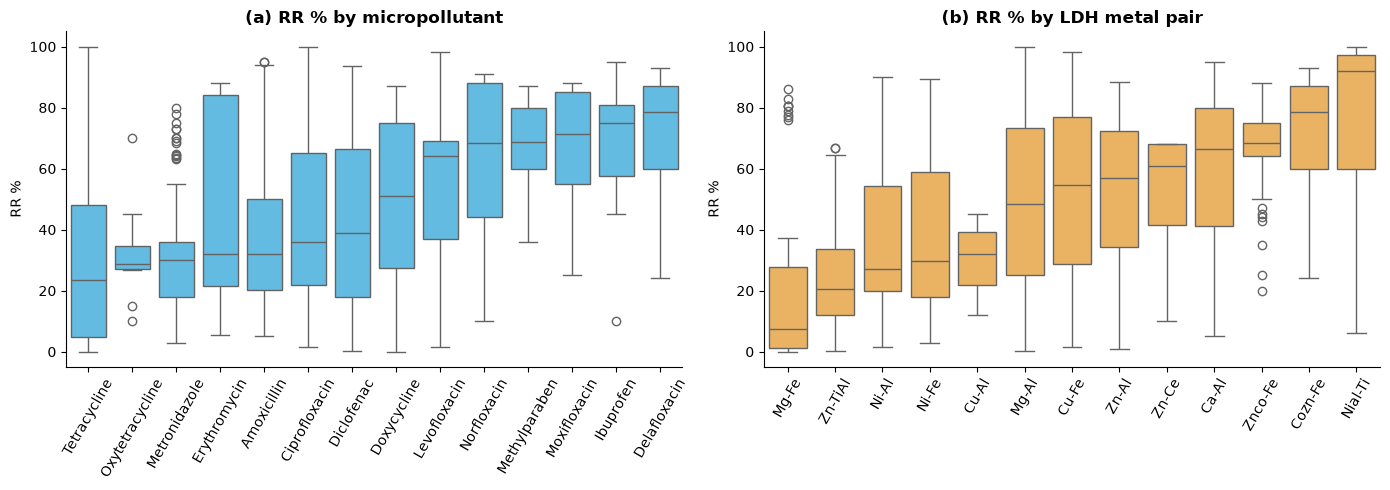

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = df.groupby('TP')['RR %'].median().sort_values().index
sns.boxplot(data=df, x='TP', y='RR %', order=order, ax=axes[0], color='#4FC3F7')
axes[0].set_title('(a) RR % by micropollutant'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=60)
df['metal_pair'] = df['Metal(II)'] + '-' + df['Metal(III)']
mp_order = df.groupby('metal_pair')['RR %'].median().sort_values().index
sns.boxplot(data=df, x='metal_pair', y='RR %', order=mp_order, ax=axes[1], color='#FFB74D')
axes[1].set_title('(b) RR % by LDH metal pair'); axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_eda_rr.png', bbox_inches='tight')
plt.show()

## A7. Workflow schematic (Fig. 1 / graphical-abstract basis)

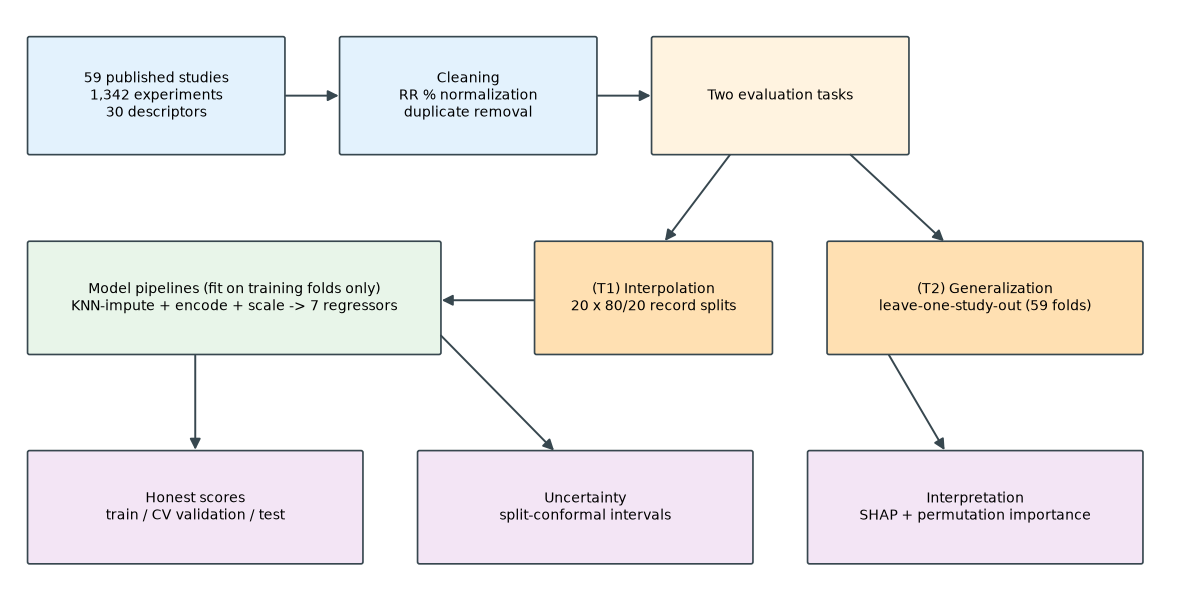

In [12]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def box(ax, xy, w, h, text, fc):
    b = FancyBboxPatch(xy, w, h, boxstyle='round,pad=0.02,rounding_size=0.02',
                       fc=fc, ec='#37474F', lw=1.2)
    ax.add_patch(b)
    ax.text(xy[0] + w/2, xy[1] + h/2, text, ha='center', va='center', fontsize=10)

def arrow(ax, p1, p2):
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle='-|>', mutation_scale=16,
                                 lw=1.4, color='#37474F'))

fig, ax = plt.subplots(figsize=(12, 6.2))
ax.set_xlim(0, 12); ax.set_ylim(0, 6.2); ax.axis('off')

box(ax, (0.2, 4.7), 2.6, 1.2, '59 published studies\n1,342 experiments\n30 descriptors', '#E3F2FD')
box(ax, (3.4, 4.7), 2.6, 1.2, 'Cleaning\nRR % normalization\nduplicate removal', '#E3F2FD')
box(ax, (6.6, 4.7), 2.6, 1.2, 'Two evaluation tasks', '#FFF3E0')
box(ax, (5.4, 2.6), 2.4, 1.15, '(T1) Interpolation\n20 x 80/20 record splits', '#FFE0B2')
box(ax, (8.4, 2.6), 3.2, 1.15, '(T2) Generalization\nleave-one-study-out (59 folds)', '#FFE0B2')
box(ax, (0.2, 2.6), 4.2, 1.15, 'Model pipelines (fit on training folds only)\n'
    'KNN-impute + encode + scale -> 7 regressors', '#E8F5E9')
box(ax, (0.2, 0.4), 3.4, 1.15, 'Honest scores\ntrain / CV validation / test', '#F3E5F5')
box(ax, (4.2, 0.4), 3.4, 1.15, 'Uncertainty\nsplit-conformal intervals', '#F3E5F5')
box(ax, (8.2, 0.4), 3.4, 1.15, 'Interpretation\nSHAP + permutation importance', '#F3E5F5')

arrow(ax, (2.8, 5.3), (3.4, 5.3))
arrow(ax, (6.0, 5.3), (6.6, 5.3))
arrow(ax, (7.4, 4.7), (6.7, 3.75))
arrow(ax, (8.6, 4.7), (9.6, 3.75))
arrow(ax, (5.4, 3.15), (4.4, 3.15))
arrow(ax, (1.9, 2.6), (1.9, 1.55))
arrow(ax, (4.4, 2.8), (5.6, 1.55))
arrow(ax, (9.0, 2.6), (9.6, 1.55))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_workflow.png', bbox_inches='tight', dpi=300)
plt.show()

## A8. Feature selection — full vs correlation-screened vs top-10 permutation set
Same protocol and hyperparameters; only the feature set changes. VIF justifies the correlation screen.

In [13]:
from sklearn.base import clone as _clone

vif = lp.vif_table(Xd)
vif.to_csv(FIG_DIR / 'vif_table.csv', index=False)
print(f"VIF: median {vif.VIF.median():.1f}, max {vif.VIF.max():.0f}, "
      f"{(vif.VIF > 10).sum()} of {len(vif)} numeric features exceed 10")

CORR_DROP = ["MW g/mol", "E", "S", "A", "B", "V", "average Pauling electronegativity",
             "average atomic weight (g/mol)", "PV cm3/g"]
top10 = ranks.sort_values('median_rank').index[:10].tolist()
FEATURE_SETS = {
    'full (30)': list(Xd.columns),
    'correlation-screened (21)': [c for c in Xd.columns if c not in CORR_DROP],
    'top-10 permutation': [c for c in top10 if c in Xd.columns],
}

def subset_models(cols, names=('Cubist', 'XGB', 'HistGB')):
    num, cat = lp.split_feature_types(Xd[cols])
    prep = lp.make_preprocessor(num, cat)
    return {n: lp.make_model_pipeline(prep, _clone(saved[n].named_steps['regressor']),
                                      with_scaler=(n in lp.NEEDS_SCALER))
            for n in names}

rows = []
for set_name, cols in FEATURE_SETS.items():
    ms = subset_models(cols)
    rep_fs = lp.repeated_interpolation(ms, Xd[cols], yd, n_repeats=20)
    loso_fs = lp.loso_evaluation({'HistGB': ms['HistGB']},
                                 X_full[cols].reset_index(drop=True),
                                 y_full.reset_index(drop=True), groups_full)
    for m, g in rep_fs.groupby('model'):
        rows.append({'feature_set': set_name, 'model': m, 'n_features': len(cols),
                     'interp_r2_mean': g.r2.mean(), 'interp_r2_std': g.r2.std(),
                     'interp_mae_mean': g.mae.mean(), 'interp_mae_std': g.mae.std(),
                     'loso_mae_median': loso_fs.mae.median() if m == 'HistGB' else np.nan})
    print(set_name, 'done', flush=True)
fs = pd.DataFrame(rows).round(3)
fs.to_csv(FIG_DIR / 'feature_selection_results.csv', index=False)
fs

/home/trunght/workspace/researches/Green-X Project-BaoTien/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/home/trunght/workspace/researches/Green-X Project-BaoTien/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/home/trunght/workspace/researches/Green-X Project-BaoTien/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/home/trunght/workspace/researches/Green-X Project-BaoTien/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence

VIF: median 66461.4, max 2463650, 22 of 26 numeric features exceed 10


full (30) done


correlation-screened (21) done


top-10 permutation done


,feature_set,model,n_features,interp_r2_mean,interp_r2_std,interp_mae_mean,interp_mae_std,loso_mae_median
0,full (30),Cubist,30,0.793,0.032,8.041,0.566,NaN
1,full (30),HistGB,30,0.850,0.028,6.344,0.530,16.400
2,full (30),XGB,30,0.842,0.029,6.277,0.558,NaN
3,correlation-screened (21),Cubist,21,0.786,0.036,8.172,0.603,NaN
4,correlation-screened (21),HistGB,21,0.849,0.027,6.425,0.469,16.238
5,correlation-screened (21),XGB,21,0.839,0.031,6.372,0.552,NaN
6,top-10 permutation,Cubist,10,0.789,0.033,8.139,0.512,NaN
7,top-10 permutation,HistGB,10,0.847,0.026,6.415,0.515,16.185
8,top-10 permutation,XGB,10,0.838,0.029,6.370,0.567,NaN


## A9. Statistical description — extended stats, Spearman vs target, composition

In [14]:
from scipy import stats as sstats

num = X_full.select_dtypes(include=[np.number])
ext = pd.DataFrame({
    'mean': num.mean(), 'std': num.std(), 'median': num.median(),
    'min': num.min(), 'max': num.max(),
    'skewness': num.skew(), 'missing_%': (num.isna().mean() * 100)}).round(2)
ext.to_csv(FIG_DIR / 'descriptor_stats_extended.csv')

rho = {}
for c in num.columns:
    m = num[c].notna()
    rho[c] = sstats.spearmanr(num.loc[m, c], y_full[m])[0]
sp = pd.Series(rho).sort_values(key=abs, ascending=False).round(3)
sp.to_csv(FIG_DIR / 'spearman_vs_target.csv')
print(sp.head(12))

cats = []
for col in ('TP', 'Metal(II)', 'Metal(III)', 'Method'):
    g = df.groupby(col).agg(records=('RR %', 'size'), studies=('Id', 'nunique'))
    g['variable'] = col
    cats.append(g.reset_index().rename(columns={col: 'level'}))
pd.concat(cats).to_csv(FIG_DIR / 'categorical_counts.csv', index=False)

print('RR% target: mean', round(y_full.mean(), 1), '| median', round(y_full.median(), 1),
      '| SD', round(y_full.std(), 1), '| skewness', round(y_full.skew(), 2))

PV cm3/g            0.426
AD g/L              0.332
E                  -0.301
APD nm              0.281
pH                  0.267
HT hour             0.233
TSPA               -0.193
S                  -0.185
Ci mg/L             0.182
d(003) nm           0.165
B                  -0.160
Calcination time    0.160
dtype: float64
RR% target: mean 45.5 | median 43.7 | SD 28.0 | skewness 0.11


## A10. SHAP depth — beeswarm summary and per-group attribution shares

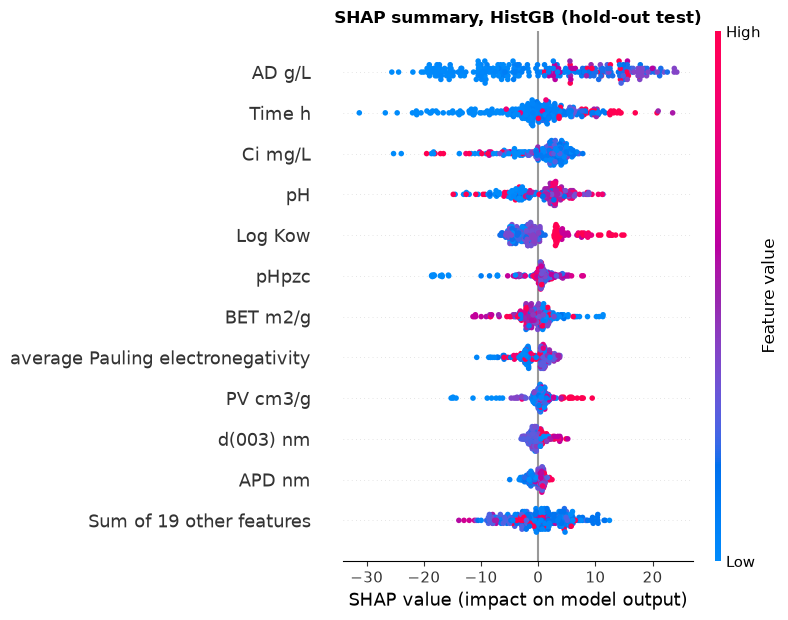

share of total |SHAP| (%):
operating conditions     54.2
texture                  17.8
composition/synthesis    14.4
micropollutant           13.5
dtype: float64


In [15]:
import shap
sv_raw, names_raw = lp.shap_summary({'model': fitted['HistGB']['model']}, Xte)
sv_raw.feature_names = names_raw

shap.plots.beeswarm(sv_raw, max_display=12, show=False)
plt.title('SHAP summary, HistGB (hold-out test)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_shap_beeswarm.png', bbox_inches='tight')
plt.show()

GROUPS = {
    'micropollutant': ['TP', 'Log Kow', 'MW g/mol', 'E', 'S', 'A', 'B', 'V', 'TSPA'],
    'composition/synthesis': ['Metal(II)', 'Metal(III)', 'M(II)/(III)', 'Method',
                              'TemH oC', 'HT hour', 'Calcination Temp', 'Calcination time',
                              'average atomic weight (g/mol)', 'average d-electron',
                              'average Pauling electronegativity'],
    'texture': ['d(003) nm', 'BET m2/g', 'PV cm3/g', 'APD nm', 'pHpzc'],
    'operating conditions': ['pH', 'Tem', 'Time h', 'AD g/L', 'Ci mg/L'],
}
mean_abs = pd.Series(np.abs(sv_raw.values).mean(axis=0), index=names_raw)
share = pd.Series({g: mean_abs[[f for f in fs_ if f in mean_abs.index]].sum()
                   for g, fs_ in GROUPS.items()})
share = (share / share.sum() * 100).round(1)
share.to_csv(FIG_DIR / 'shap_group_share.csv')
print('share of total |SHAP| (%):'); print(share.sort_values(ascending=False))

## A11. Bootstrap inferential statistics
Bootstrap 95% CIs for the leading Spearman correlations and for subgroup median contrasts (significance = CI excludes zero); paired Wilcoxon between the top models across the 20 repeated splits.

In [16]:
from scipy import stats as sstats
rng = np.random.default_rng(SEED)
N_BOOT = 2000

num_full = X_full.select_dtypes(include=[np.number])
lead = ['PV cm3/g', 'AD g/L', 'E', 'APD nm', 'pH', 'HT hour', 'TSPA', 'S',
        'Ci mg/L', 'd(003) nm', 'B', 'Calcination time']
rows = []
for c in lead:
    m = num_full[c].notna().to_numpy()
    xv, yv = num_full[c].to_numpy()[m], y_full.to_numpy()[m]
    rho = sstats.spearmanr(xv, yv)[0]
    boots = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, len(xv), len(xv))
        boots.append(sstats.spearmanr(xv[idx], yv[idx])[0])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    rows.append({'descriptor': c, 'rho': rho, 'ci_lo': lo, 'ci_hi': hi,
                 'excludes_zero': (lo > 0) or (hi < 0), 'n': int(m.sum())})
sp_ci = pd.DataFrame(rows).round(3)
sp_ci.to_csv(FIG_DIR / 'bootstrap_spearman_ci.csv', index=False)
print(sp_ci.to_string(index=False))

      descriptor    rho  ci_lo  ci_hi  excludes_zero    n
        PV cm3/g  0.426  0.371  0.474           True 1003
          AD g/L  0.332  0.284  0.380           True 1342
               E -0.301 -0.352 -0.250           True 1342
          APD nm  0.281  0.224  0.335           True 1155
              pH  0.267  0.213  0.317           True 1342
         HT hour  0.233  0.180  0.286           True 1163
            TSPA -0.193 -0.249 -0.139           True 1342
               S -0.185 -0.239 -0.133           True 1342
         Ci mg/L  0.182  0.127  0.233           True 1342
       d(003) nm  0.165  0.114  0.217           True 1308
               B -0.160 -0.217 -0.099           True 1342
Calcination time  0.160  0.055  0.265           True  457


In [17]:
def median_diff_ci(a, b, n_boot=5000):
    a, b = np.asarray(a, float), np.asarray(b, float)
    diff = np.median(a) - np.median(b)
    boots = [np.median(rng.choice(a, len(a))) - np.median(rng.choice(b, len(b)))
             for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return diff, lo, hi

mp = df['Metal(II)'] + '-' + df['Metal(III)']
contrasts = {
    'Zn-Al vs Mg-Al': (y_full[mp == 'Zn-Al'], y_full[mp == 'Mg-Al']),
    'calcined vs uncalcined': (y_full[df['Calcination Temp'].notna()],
                               y_full[df['Calcination Temp'].isna()]),
    'diclofenac vs tetracycline': (y_full[df.TP == 'Diclofenac'],
                                   y_full[df.TP == 'Tetracycline']),
}
rows = []
for name, (a, b) in contrasts.items():
    d, lo, hi = median_diff_ci(a, b)
    rows.append({'contrast': name, 'median_diff': d, 'ci_lo': lo, 'ci_hi': hi,
                 'excludes_zero': (lo > 0) or (hi < 0),
                 'n_a': len(a), 'n_b': len(b)})
sub_ci = pd.DataFrame(rows).round(2)
sub_ci.to_csv(FIG_DIR / 'subgroup_median_ci.csv', index=False)
print(sub_ci.to_string(index=False))

r = pd.read_csv(FIG_DIR / 'repeated_interp_models.csv')
piv = r.pivot(index='repeat', columns='model', values='mae')
w = sstats.wilcoxon(piv['HistGB'], piv['XGB'])
print(f"Wilcoxon HistGB vs XGB MAE over 20 splits: W={w.statistic:.0f}, p={w.pvalue:.3f}")
pd.DataFrame([{'pair': 'HistGB vs XGB', 'W': w.statistic, 'p': w.pvalue}]).to_csv(
    FIG_DIR / 'wilcoxon_models.csv', index=False)

                  contrast  median_diff  ci_lo  ci_hi  excludes_zero  n_a  n_b
            Zn-Al vs Mg-Al         8.72  -0.66  17.17          False  128  561
    calcined vs uncalcined        10.11   1.73  17.85           True  457  885
diclofenac vs tetracycline        15.45   8.28  27.29           True  304  208
Wilcoxon HistGB vs XGB MAE over 20 splits: W=72, p=0.231


## A12. Error-tolerance distribution and screening-threshold classification
Per-row predictions under both tasks: interpolation reference split (HistGB) and pooled leave-one-study-out predictions (Cubist and HistGB).

Cubist LOSO preds done


HistGB LOSO preds done


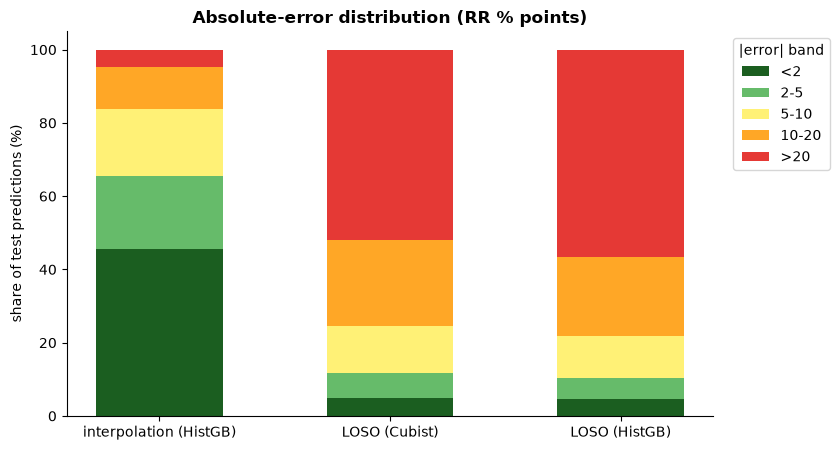

,task,threshold,precision,recall,f1,positives_true,n
0,interpolation (HistGB),80.0,0.917,0.579,0.710,38,252
1,LOSO (Cubist),80.0,0.316,0.059,0.100,203,1342
2,LOSO (HistGB),80.0,0.167,0.010,0.019,203,1342


In [18]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import precision_score, recall_score, f1_score

def loso_predictions(model, Xf, yf, grp):
    preds = pd.Series(index=Xf.index, dtype=float)
    for tr, te in LeaveOneGroupOut().split(Xf, yf, grp):
        m = _clone(model)
        m.fit(Xf.iloc[tr], yf.iloc[tr])
        preds.iloc[te] = m.predict(Xf.iloc[te])
    return preds

pred_sets = {'interpolation (HistGB)':
                 (np.asarray(yte, float), fitted['HistGB']['model'].predict(Xte))}
Xr, yr = X_full.reset_index(drop=True), y_full.reset_index(drop=True)
for name in ('Cubist', 'HistGB'):
    p = loso_predictions(saved[name], Xr, yr, groups_full)
    pred_sets[f'LOSO ({name})'] = (yr.to_numpy(), p.to_numpy())
    print(name, 'LOSO preds done', flush=True)

BANDS = [(0, 2), (2, 5), (5, 10), (10, 20), (20, np.inf)]
rows = []
for task, (yt, yp) in pred_sets.items():
    err = np.abs(yt - yp)
    for lo, hi in BANDS:
        rows.append({'task': task, 'band': f'{lo}-{"inf" if np.isinf(hi) else hi}',
                     'pct': 100 * ((err >= lo) & (err < hi)).mean()})
eb = pd.DataFrame(rows).round(1)
eb.to_csv(FIG_DIR / 'error_bands.csv', index=False)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
bottom = np.zeros(len(pred_sets))
colors = ['#1B5E20', '#66BB6A', '#FFF176', '#FFA726', '#E53935']
labels = ['<2', '2-5', '5-10', '10-20', '>20']
tasks = list(pred_sets)
for (band, color, lab) in zip(range(5), colors, labels):
    vals = [eb[(eb.task == t)].iloc[band].pct for t in tasks]
    ax.bar(tasks, vals, bottom=bottom, color=color, label=lab, width=0.55)
    bottom += np.array(vals)
ax.set_ylabel('share of test predictions (%)')
ax.set_title('Absolute-error distribution (RR % points)')
ax.legend(title='|error| band', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_error_bands.png', bbox_inches='tight')
plt.show()

THR = 80.0
rows = []
for task, (yt, yp) in pred_sets.items():
    tb, pb = (yt >= THR).astype(int), (yp >= THR).astype(int)
    rows.append({'task': task, 'threshold': THR,
                 'precision': precision_score(tb, pb, zero_division=0),
                 'recall': recall_score(tb, pb, zero_division=0),
                 'f1': f1_score(tb, pb, zero_division=0),
                 'positives_true': int(tb.sum()), 'n': len(tb)})
sc = pd.DataFrame(rows).round(3)
sc.to_csv(FIG_DIR / 'screening_classification.csv', index=False)
sc

## A13. Stratified performance matrix and parity/bias diagnostics

In [19]:
attrs2 = (df.groupby('Id').agg(tp=('TP', lambda s: s.mode().iat[0]))
          .reset_index().rename(columns={'Id': 'study'}))
lm = loso.merge(attrs2, on='study')
tp_keep = lm[lm.model == 'Cubist'].tp.value_counts()
tp_keep = tp_keep[tp_keep >= 3].index
strat = (lm[lm.tp.isin(tp_keep)]
         .pivot_table(index='tp', columns='model', values='mae', aggfunc='median')
         .round(1).sort_values('Cubist'))
strat.to_csv(FIG_DIR / 'stratified_performance.csv')
strat

model,ANN,Cubist,HistGB,KNN,LR,RF,XGB
tp,,,,,,,
Ciprofloxacin,13.4,5.4,5.0,7.0,28.4,6.4,4.2
Doxycycline,56.0,15.2,16.4,42.4,31.7,26.4,25.5
Amoxicillin,13.2,17.2,28.2,11.9,14.7,29.4,28.4
Tetracycline,43.6,20.7,23.9,24.4,22.3,26.3,23.7
Diclofenac,59.1,21.8,18.3,38.3,71.1,20.0,18.3
Levofloxacin,33.7,22.2,24.0,31.8,30.5,20.8,25.2


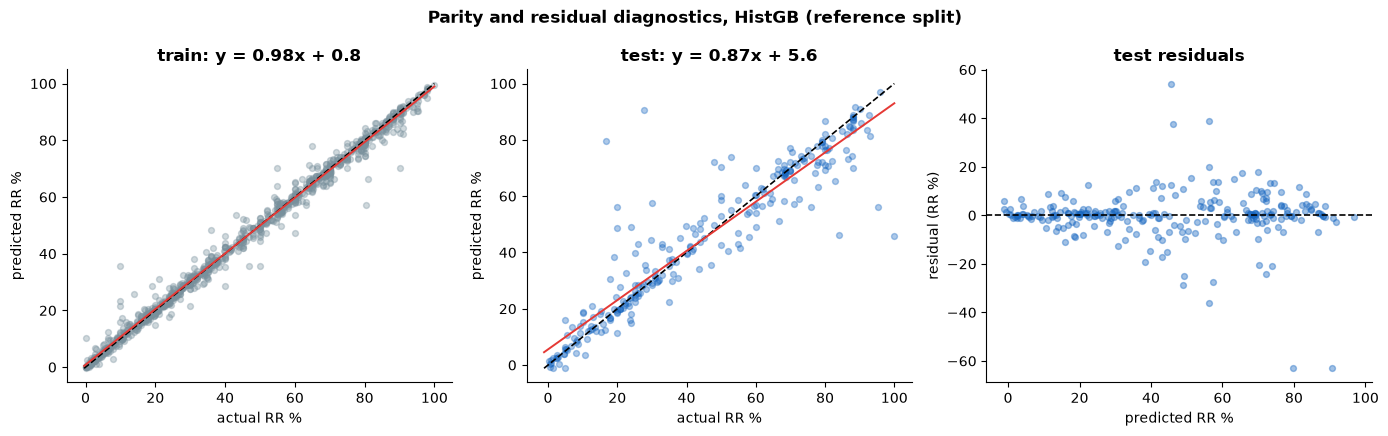

         mean    std
model               
HistGB  0.830  0.032
XGB     0.820  0.033
Cubist  0.764  0.037
RF      0.755  0.038
KNN     0.697  0.069
ANN     0.473  0.052
LR      0.318  0.045


In [20]:
m = fitted['HistGB']['model']
ptr, pte = m.predict(Xtr), m.predict(Xte)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, (yy, pp, lab, col) in zip(axes[:2], [
        (np.asarray(ytr, float), ptr, 'train', '#78909C'),
        (np.asarray(yte, float), pte, 'test', '#1565C0')]):
    a, b = np.polyfit(yy, pp, 1)
    ax.scatter(yy, pp, alpha=0.35, s=18, color=col)
    lims = [min(yy.min(), pp.min()), max(yy.max(), pp.max())]
    ax.plot(lims, lims, 'k--', lw=1.2)
    xs = np.linspace(*lims, 10)
    ax.plot(xs, a * xs + b, color='#E53935', lw=1.4)
    ax.set_title(f'{lab}: y = {a:.2f}x + {b:.1f}')
    ax.set_xlabel('actual RR %'); ax.set_ylabel('predicted RR %')
res = np.asarray(yte, float) - pte
axes[2].scatter(pte, res, alpha=0.4, s=18, color='#1565C0')
axes[2].axhline(0, color='k', ls='--', lw=1.2)
axes[2].set_title('test residuals'); axes[2].set_xlabel('predicted RR %')
axes[2].set_ylabel('residual (RR %)')
plt.suptitle('Parity and residual diagnostics, HistGB (reference split)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_parity_diag.png', bbox_inches='tight')
plt.show()

n_te, p_feat = len(yte), Xd.shape[1]
r = pd.read_csv(FIG_DIR / 'repeated_interp_models.csv')
r['adj_r2'] = 1 - (1 - r.r2) * (n_te - 1) / (n_te - p_feat - 1)
adj = r.groupby('model')['adj_r2'].agg(['mean', 'std']).round(3)
adj.to_csv(FIG_DIR / 'adjusted_r2.csv')
print(adj.sort_values('mean', ascending=False))